In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime
from itertools import product

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [4]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

## Load agent and decoder

In [5]:
def load_agent_and_env(checkpoint_path, task='cartpole-swingup'):
    """Load agent and environment with the specified checkpoint.
    
    Args:
        checkpoint_path: Path to the checkpoint file
        
    Returns:
        tuple: (agent, env, cfg) - loaded agent, environment, and config
    """
    # Base configuration
    override_cfg = dict(
        task=task,
        checkpoint=checkpoint_path,
        obs='state',
        seed=0,
        compile=False,
        mpc=True,
        multitask=False,
        model_size=5,
        save_video=False,  # Disable video to speed up sweep
        record_planning=False,  # Focus on episode data
    )

    with initialize(config_path="tdmpc2", version_base=None):
        cfg = compose(config_name="config")
        OmegaConf.set_struct(cfg, False)
        cfg = OmegaConf.merge(cfg, override_cfg)

    # Parse config
    cfg = parse_cfg(cfg)
    set_seed(cfg.seed)

    # cfg.initial_state = {
    #     'qpos': {
    #         'slider': 0,  #cart position
    #         'hinge_1': 0,  # pole angle
    #     },
    # }

    env = make_env(cfg)

    print("\nLoading agent...")
    agent = TDMPC2(cfg)

    # Optionally load checkpoint
    if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
        print(f"Loading checkpoint: {cfg.checkpoint}")
        agent.load(cfg.checkpoint)

    return agent, env

In [26]:
import pickle
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/decoder.pkl',
        'rb') as f:
    decoder_ckpt_3 = pickle.load(f)


In [163]:
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████| 108/108 [00:00<00:00, 10084.03it/s]


Found 108 configurations
Found 108 configurations


  0%|          | 0/108 [00:00<?, ?it/s]

100%|██████████| 108/108 [00:00<00:00, 248.57it/s]


In [164]:
df_metadata_ckp3 = load_sweep_metadata(
    ["logs/25-12-09-cartpole_initial_conditions_seeds_models"],
    json_file_name='episode_metadata.json')

df_metadata_ckp3 = df_metadata_ckp3[(
    df_metadata_ckp3['checkpoint'] == 'ckpts/cartpole-swingup-3.pt')]

df_ckp3 = load_data(
    df_metadata_ckp3,
    episode_file_name='episode_data.pkl',
    cart_position=[-1.0, 0.0, 1.0],
)

df_ckp3['ckpt_int'] = 4_000_000

Dirs in logs/25-12-09-cartpole_initial_conditions_seeds_models:   0%|          | 0/825 [00:00<?, ?it/s]

Dirs in logs/25-12-09-cartpole_initial_conditions_seeds_models: 100%|██████████| 825/825 [00:00<00:00, 12074.80it/s]


Found 825 configurations
Found 165 configurations


100%|██████████| 165/165 [00:00<00:00, 366.96it/s]


In [165]:
df = pd.concat([df, df_ckp3])
df.shape

(273, 19)

## Fit linear probe per checkpoint

In [166]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Fit linear probe for each checkpoint
probes = {}
for ckpt in df['ckpt_int'].unique():
    print(f"Processing checkpoint: {ckpt}")
    df_ckpt = df[df['ckpt_int'] == ckpt]

    # Collect all latents and observations
    all_latents = []
    all_observations = []

    # Concatenate all episodes
    X = np.concatenate(df_ckpt['latent_states'].tolist())
    y = np.concatenate(df_ckpt['observations'].tolist())
    print(X.shape, y.shape)
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,
                                                        y,
                                                        test_size=0.2,
                                                        random_state=42)

    # Fit linear probe for each observation dimension
    probe = LinearRegression()
    probe.fit(X_train, y_train)
    y_pred = probe.predict(X_test)
    r2 = r2_score(y_test, y_pred)

    print(f"R²: {np.mean(r2):.4f}")
    probes[ckpt] = probe

probes[4_000_000] = decoder_ckpt_3

Processing checkpoint: 100000
(9000, 512) (9000, 5)
R²: 1.0000
Processing checkpoint: 25000
(9000, 512) (9000, 5)
R²: 1.0000
Processing checkpoint: 500000
(9000, 512) (9000, 5)
R²: 1.0000
Processing checkpoint: 3000000
(9000, 512) (9000, 5)
R²: 1.0000
Processing checkpoint: 1000000
(9000, 512) (9000, 5)
R²: 0.9999
Processing checkpoint: 50000
(9000, 512) (9000, 5)
R²: 1.0000
Processing checkpoint: 4000000
(82500, 512) (82500, 5)
R²: 0.9977


## Plot initial conditions

In [167]:
from analysis.utils import reconstruct_frame
from dm_control import suite

In [168]:
env = suite.load("cartpole", "swingup")
initial_angles = np.array([0., 72., 144., 216., 288., 360.])
results_frames = {}
for initial_angle in initial_angles:

    initial_angle_radians = np.radians(initial_angle)
    initial_state = np.array([0., initial_angle_radians, 0., 0.])
    frame = reconstruct_frame(initial_state, env)
    results_frames[initial_angle] = frame

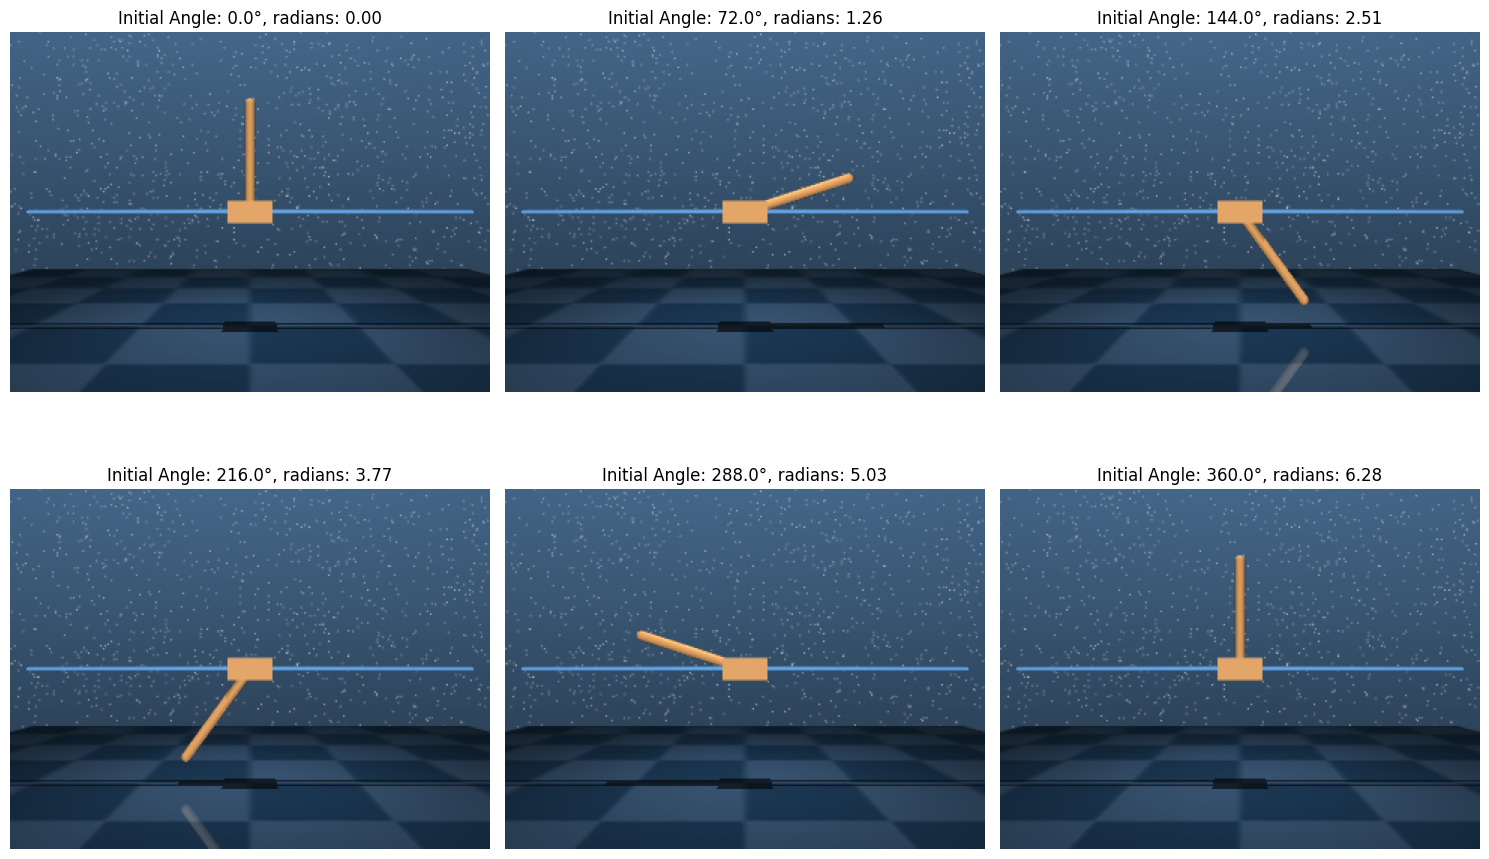

In [169]:
# Plot the frames for each initial angle
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (angle, frame) in enumerate(sorted(results_frames.items())):
    axes[idx].imshow(frame)
    axes[idx].set_title(
        f'Initial Angle: {angle}°, radians: {np.radians(angle):.2f}',
        fontsize=12)
    axes[idx].axis('off')

# Hide the last subplot since we only have 5 angles
axes[-1].axis('off')

plt.tight_layout()
plt.show()

## Does training improve performance?

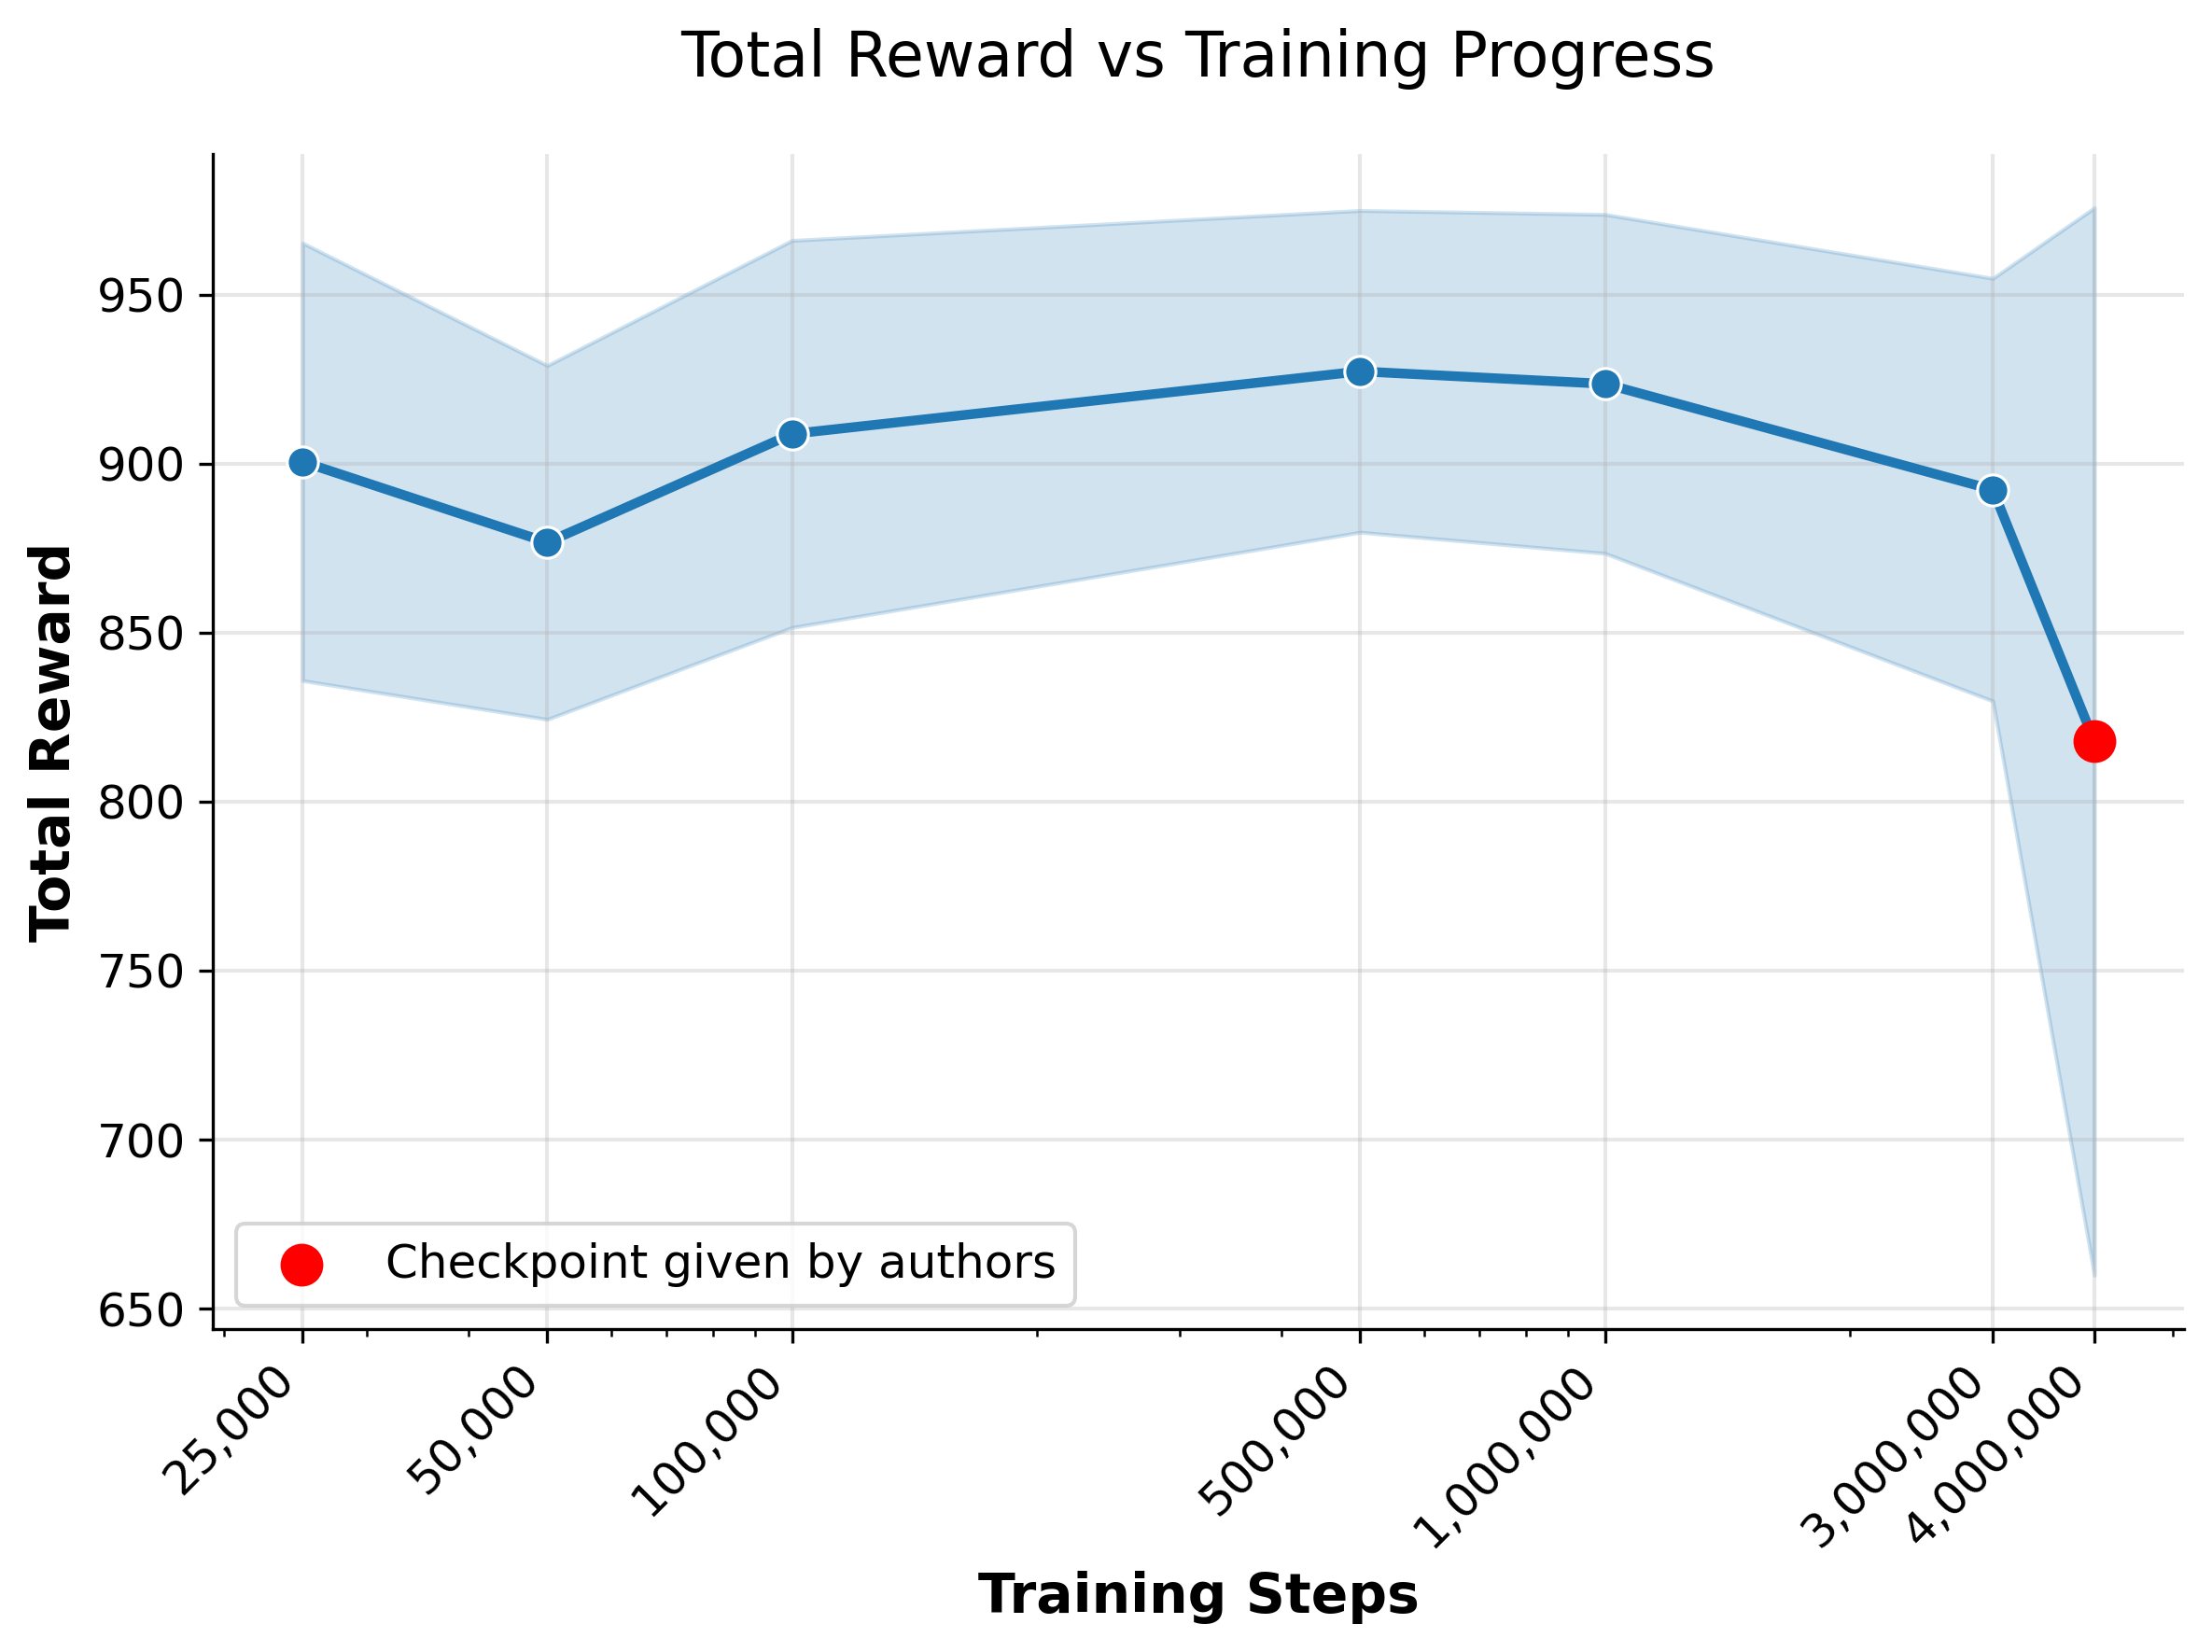

In [179]:
# Plot total reward vs checkpoint
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
sns.lineplot(data=df,
             x='ckpt_int',
             y='total_reward',
             marker='o',
             errorbar='sd',
             linewidth=2.5,
             markersize=8,
             ax=ax)
ax.set_xscale('log')
ax.set_xlabel('Training Steps', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Reward', fontsize=14, fontweight='bold')
ax.set_title(
    'Total Reward vs Training Progress',
    fontsize=16,
    #fontweight='bold',
    pad=20)
ax.grid(True, alpha=0.3, linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=12)

# Set x-axis ticks to show actual checkpoint values
checkpoint_values = sorted(df['ckpt_int'].unique())
ax.set_xticks(checkpoint_values)
ax.set_xticklabels([f'{int(x):,}' for x in checkpoint_values],
                   rotation=45,
                   ha='right')

# Highlight the last checkpoint (from authors) in red
last_checkpoint = checkpoint_values[-1]
last_checkpoint_data = df[df['ckpt_int'] == last_checkpoint]
ax.scatter(last_checkpoint,
           last_checkpoint_data['total_reward'].mean(),
           color='red',
           s=100,
           zorder=5,
           label='Checkpoint given by authors')
ax.legend(fontsize=12)

# Add spine styling
sns.despine(ax=ax)

plt.tight_layout()
plt.show()


## Does training improve the accuracy of the dynamics model?

In [95]:
def run_env_autonomous(env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    #env.reset()
    obs_list = []
    obs_list.append(obs)
    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))
        obs_list.append(next_obs)

    return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    z = agent.model.encode(obs.to(agent.device), task=None)

    obs_list = []
    obs_list.append(obs)
    z_list = []
    z_list.append(z.cpu().numpy())
    for _ in range(n_steps - 1):
        #next_obs, *_ = env.step(torch.tensor([0.0]))

        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())
        #obs_list.append(next_obs)

    return np.array(z_list)

In [96]:
# Example usage:
# CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'

In [97]:
from pathlib import Path

MODELS_DIR = Path(
    'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models')  # normal
# MODELS_DIR = Path(
#     'logs/model-runs/2025-12-20/19-06-08/cartpole_exp/models')  # custom

MODEL_STEPS = [
    25_000,  # Early training
    50_000,  # Mid-early training
    100_000,  # Mid training
    500_000,  # Late training
    1_000_000,  # Near convergence
    3_000_000,  # Final checkpoint
]

# Get list of all model checkpoint paths
MODEL_PATHS = [MODELS_DIR / f"{step}.pt" for step in MODEL_STEPS]

#MODEL_PATHS = []
# MODEL_PATHS.append(
#     Path('/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-1.pt'))
# MODEL_PATHS.append(
#     Path('/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-2.pt'))
MODEL_PATHS.append(
    Path('/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'))

In [98]:
MODEL_PATHS

[PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/25000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/50000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/100000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/1000000.pt'),
 PosixPath('logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/3000000.pt'),
 PosixPath('/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt')]

In [ ]:
intital_positions = [0]
#initial_angles = np.array([36., 72., 144., 216., 288.])
initial_angles = np.linspace(0, 360, 11)[1:-1]
steps_to_run = 50

results = {}

prod_list = list(product(intital_positions, initial_angles, MODEL_PATHS))
for initial_position, initial_angle, model_path in tqdm(prod_list):

    agent, env = load_agent_and_env(model_path)
    if model_path == Path(
            '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'):
        ckpt_int = 4_000_000
    elif model_path == Path(
            '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-2.pt'):
        ckpt_int = 2
    elif model_path == Path(
            '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-1.pt'):
        ckpt_int = 1
    else:
        ckpt_int = int(str(model_path).split('/')[-1].split('.')[0])
    initial_angle_radians = np.radians(initial_angle)
    initial_state = {
        'qpos': {
            'slider': initial_position,  #cart position
            'hinge_1': initial_angle_radians,  # pole angle
        },
        'qvel': {
            'slider': 0,  #cart velocity
            'hinge_1': 0,  # pole angular velocity
        }
    }

    probe_decoder = probes[ckpt_int]

    obs_true = run_env_autonomous(env, initial_state, steps_to_run)
    z_true = agent.model.encode(torch.from_numpy(obs_true).to(agent.device),
                                task=None).detach().cpu().numpy()

    z_predicted = run_dynamics_model(agent, env, initial_state, steps_to_run)
    assert z_predicted.shape == z_true.shape
    obs_predicted = probe_decoder.predict(z_predicted)

    # dict_results_steps = {}
    # for k in list(range(1, 10 + 1)) + [50]:
    #     z_predicted_steps, obs_true_steps = run_dynamics_model_in_steps(
    #         agent, env, initial_state, n_steps=steps_to_run, k=k)
    #     obs_predicted_steps = decoder.predict(z_predicted_steps)
    #     dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
    #     #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
    #     dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

    errors_latent = ((z_true - z_predicted)**2).mean(1)
    errors_physical = ((obs_true - obs_predicted)**2).mean(1)
    error_physical_per_dim = [
        ((obs_true[:, i] - obs_predicted[:, i])**2).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        ((z_true[:, i] - z_predicted[:, i])**2).mean() for i in range(512)
    ]
    # errors_physical = (abs(obs_true - obs_predicted)).mean(1)
    # error_physical_per_dim = [
    #     (abs(obs_true[:, i] - obs_predicted[:, i])).mean() for i in range(5)
    # ]
    # error_latent_per_dim = [
    #     (abs(z_true[:, i] - z_predicted[:, i])).mean() for i in range(512)
    # ]

    r2_physical = r2_score(obs_true, obs_predicted)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_predicted[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)

    results[(ckpt_int, initial_position, initial_angle)] = {
        'obs_true': obs_true,
        'obs_predicted': obs_predicted,
        'z_true': z_true,
        'z_predicted': z_predicted,
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
    }

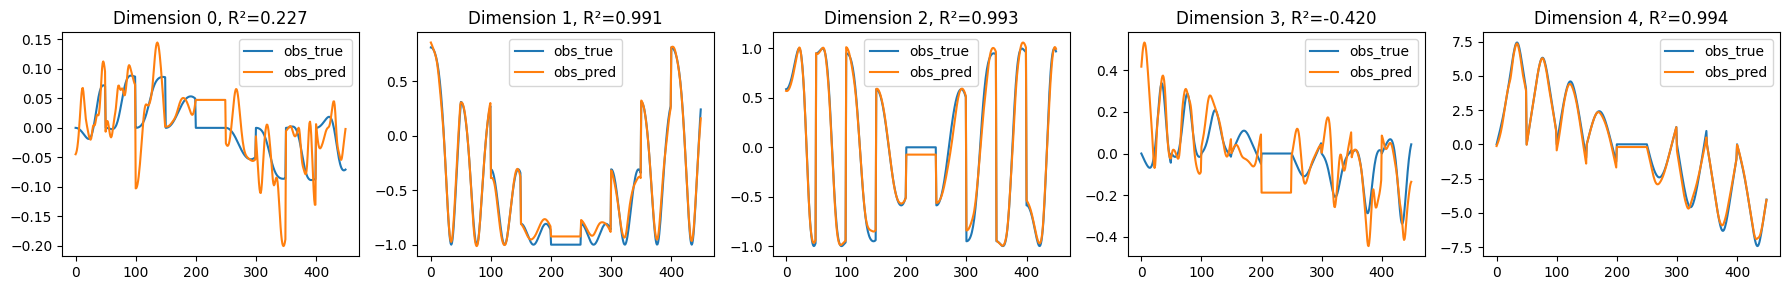

In [185]:
# Collect data for one checkpoint across all initial conditions
selected_ckpt = 3_000_000

# Stack all z_true and obs_true for this checkpoint
z_true_all = []
obs_true_all = []

for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int == selected_ckpt:
        z_true_all.append(results[key]['z_true'])
        obs_true_all.append(results[key]['obs_true'])

# Stack them together
z_true_stacked = np.vstack(z_true_all)
obs_true_stacked = np.vstack(obs_true_all)

# Predict on all stacked data
obs_pred_stacked = probes[selected_ckpt].predict(z_true_stacked)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for dim in range(5):
    r2 = r2_score(obs_true_stacked[:, dim], obs_pred_stacked[:, dim])
    axes[dim].plot(obs_true_stacked[:, dim], label='obs_true')
    axes[dim].plot(obs_pred_stacked[:, dim], label='obs_pred')
    axes[dim].set_title(f'Dimension {dim}, R²={r2:.3f}')
    axes[dim].legend()
plt.tight_layout()
plt.show()

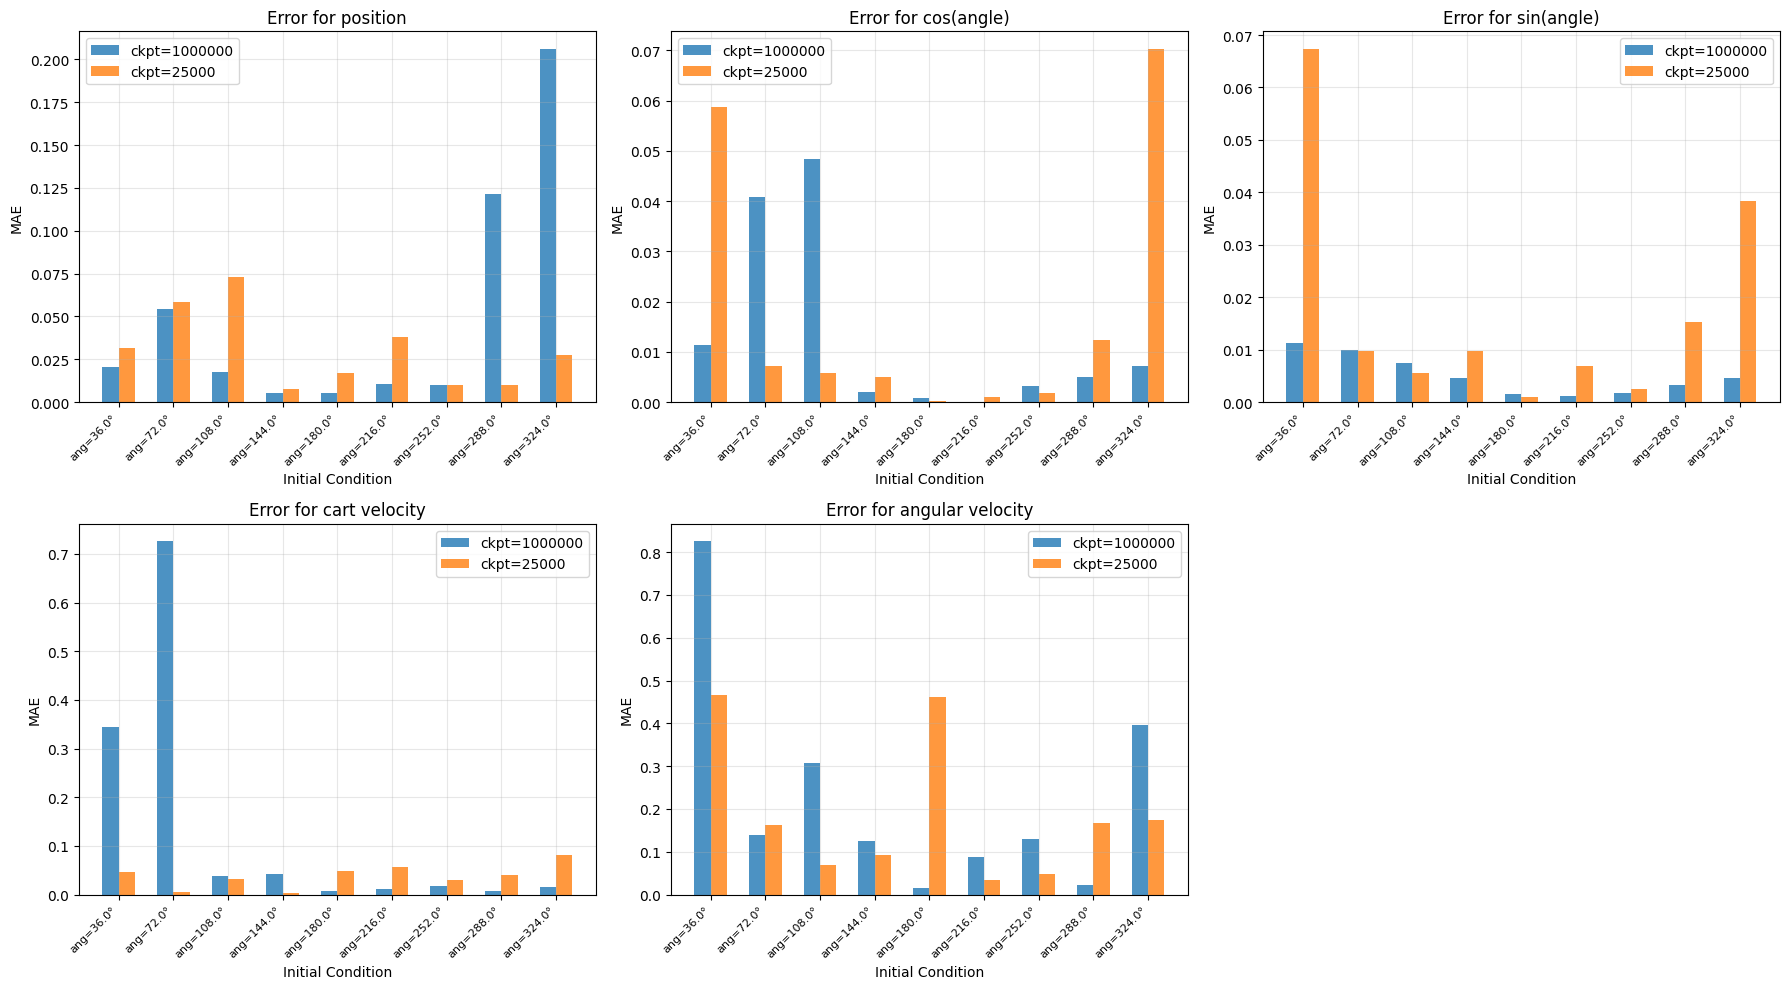

In [101]:
# Plot error_physical_per_dim for two checkpoints across all initial conditions
selected_ckpt1 = 1_000_000  # Choose a checkpoint to analyze
selected_ckpt2 = 25_000  # Choose a checkpoint to analyze

# Collect data for both checkpoints
initial_conditions = []
errors_per_dim_per_ic_ckpt1 = {i: [] for i in range(5)}
errors_per_dim_per_ic_ckpt2 = {i: [] for i in range(5)}

for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int == selected_ckpt1:
        if (initial_position, initial_angle) not in initial_conditions:
            initial_conditions.append((initial_position, initial_angle))
        error_per_dim = results[key]['error_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt1[dim].append(error_per_dim[dim])
    elif ckpt_int == selected_ckpt2:
        error_per_dim = results[key]['error_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt2[dim].append(error_per_dim[dim])

# Option to sort by angle proximity to 0/360 degrees
sort_by_angle_proximity = False  # Set to True to sort by proximity to 0/360

if sort_by_angle_proximity:
    # Sort initial conditions by how close angle is to 0/360 degrees
    # Use min distance to 0 or 360
    def angle_distance_to_zero(angle):
        return min(abs(angle), abs(angle - 360))

    # Create list of (index, initial_condition) pairs and sort
    indexed_ics = list(enumerate(initial_conditions))
    indexed_ics.sort(key=lambda x: angle_distance_to_zero(x[1][1]))

    # Reorder everything according to the sorted indices
    sort_indices = [idx for idx, _ in indexed_ics]
    initial_conditions = [initial_conditions[i] for i in sort_indices]

    for dim in range(5):
        errors_per_dim_per_ic_ckpt1[dim] = [
            errors_per_dim_per_ic_ckpt1[dim][i] for i in sort_indices
        ]
        errors_per_dim_per_ic_ckpt2[dim] = [
            errors_per_dim_per_ic_ckpt2[dim][i] for i in sort_indices
        ]

# Create labels for initial conditions
ic_labels = [f"ang={ang:.1f}°" for pos, ang in initial_conditions]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

x = np.arange(len(initial_conditions))
width = 0.3  # Width of bars

for dim in range(5):
    ax = axes[dim]
    ax.bar(x - width / 2,
           errors_per_dim_per_ic_ckpt1[dim],
           width,
           label=f'ckpt={selected_ckpt1}',
           alpha=0.8)
    ax.bar(x + width / 2,
           errors_per_dim_per_ic_ckpt2[dim],
           width,
           label=f'ckpt={selected_ckpt2}',
           alpha=0.8)
    ax.set_xlabel('Initial Condition')
    ax.set_ylabel('MAE')
    ax.set_title(f'Error for {variable_names[dim]}')
    ax.set_xticks(x)
    ax.set_xticklabels(ic_labels, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove the extra subplot
axes[5].remove()

plt.tight_layout()
plt.show()

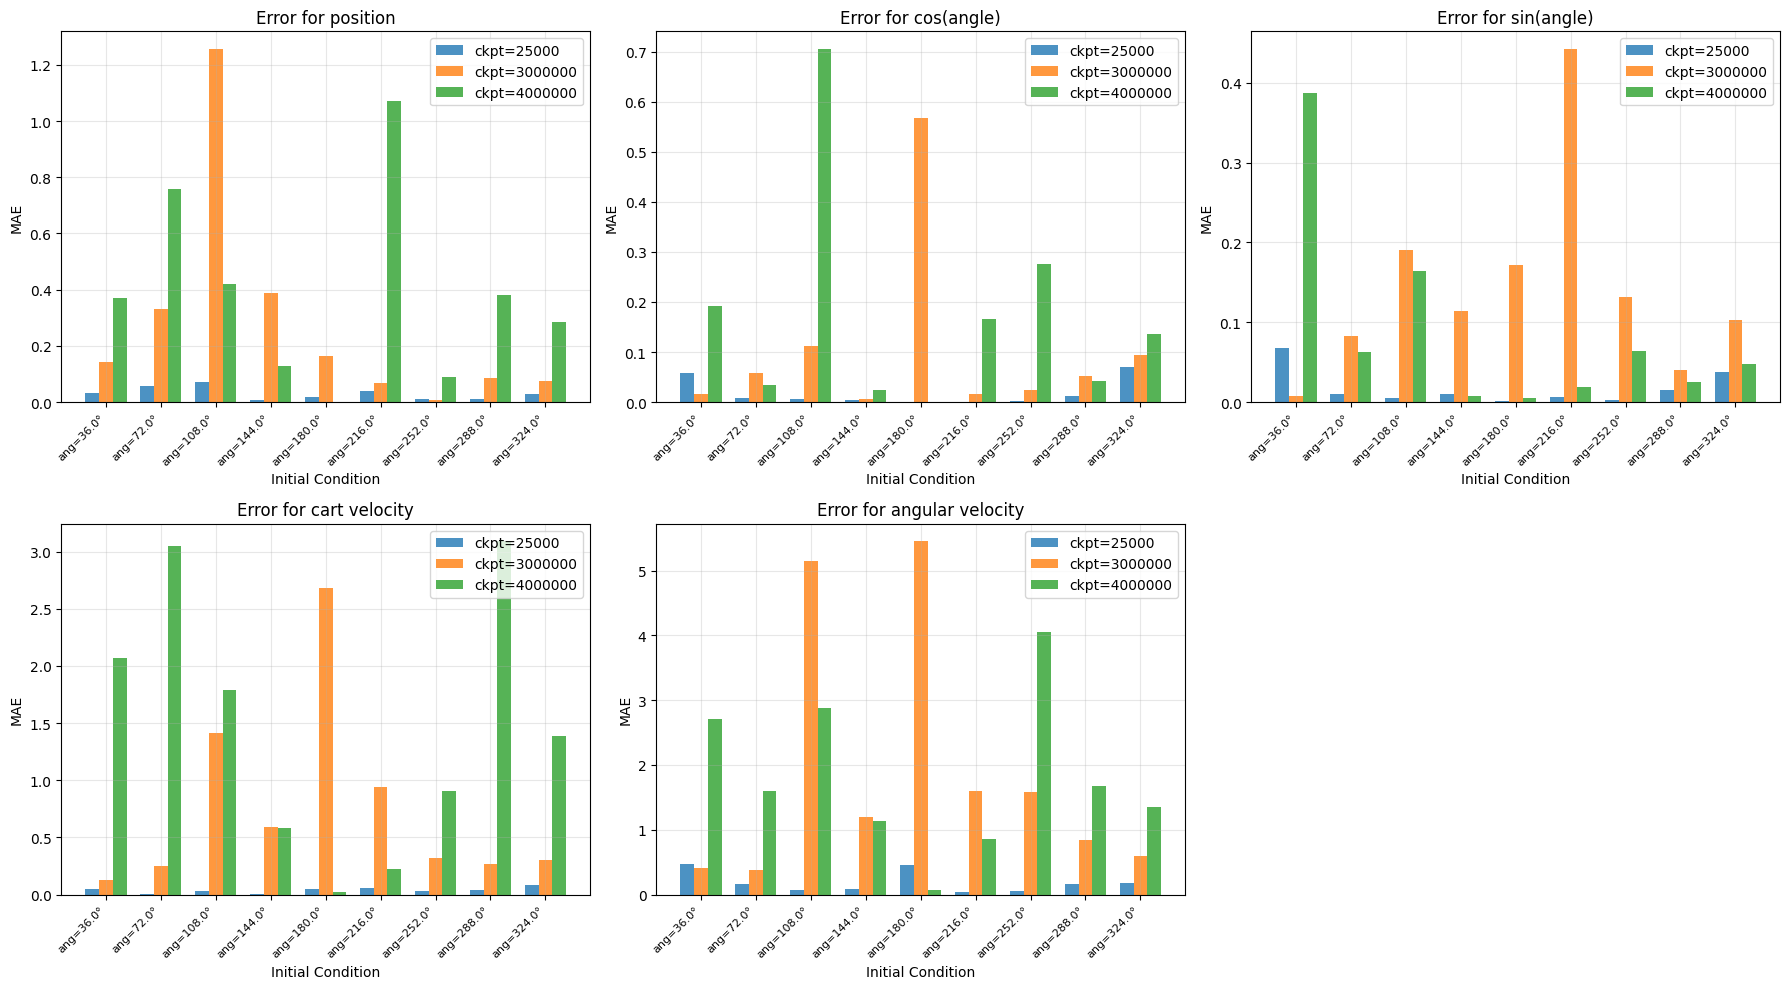

In [180]:
# Plot error_physical_per_dim for three checkpoints across all initial conditions
selected_ckpt1 = 25_000  # Choose a checkpoint to analyze
selected_ckpt2 = 3_000_000  # Choose a checkpoint to analyze
selected_ckpt3 = 4_000_000  # Choose a checkpoint to analyze

# Collect data for all three checkpoints
initial_conditions = []
errors_per_dim_per_ic_ckpt1 = {i: [] for i in range(5)}
errors_per_dim_per_ic_ckpt2 = {i: [] for i in range(5)}
errors_per_dim_per_ic_ckpt3 = {i: [] for i in range(5)}

for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int == selected_ckpt1:
        if (initial_position, initial_angle) not in initial_conditions:
            initial_conditions.append((initial_position, initial_angle))
        error_per_dim = results[key]['error_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt1[dim].append(error_per_dim[dim])
    elif ckpt_int == selected_ckpt2:
        error_per_dim = results[key]['error_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt2[dim].append(error_per_dim[dim])
    elif ckpt_int == selected_ckpt3:
        error_per_dim = results[key]['error_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt3[dim].append(error_per_dim[dim])

# Option to sort by angle proximity to 0/360 degrees
sort_by_angle_proximity = False  # Set to True to sort by proximity to 0/360

if sort_by_angle_proximity:
    # Sort initial conditions by how close angle is to 0/360 degrees
    # Use min distance to 0 or 360
    def angle_distance_to_zero(angle):
        return min(abs(angle), abs(angle - 360))

    # Create list of (index, initial_condition) pairs and sort
    indexed_ics = list(enumerate(initial_conditions))
    indexed_ics.sort(key=lambda x: angle_distance_to_zero(x[1][1]))

    # Reorder everything according to the sorted indices
    sort_indices = [idx for idx, _ in indexed_ics]
    initial_conditions = [initial_conditions[i] for i in sort_indices]

    for dim in range(5):
        errors_per_dim_per_ic_ckpt1[dim] = [
            errors_per_dim_per_ic_ckpt1[dim][i] for i in sort_indices
        ]
        errors_per_dim_per_ic_ckpt2[dim] = [
            errors_per_dim_per_ic_ckpt2[dim][i] for i in sort_indices
        ]
        errors_per_dim_per_ic_ckpt3[dim] = [
            errors_per_dim_per_ic_ckpt3[dim][i] for i in sort_indices
        ]

# Create labels for initial conditions
ic_labels = [f"ang={ang:.1f}°" for pos, ang in initial_conditions]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

x = np.arange(len(initial_conditions))
width = 0.25  # Width of bars (adjusted for 3 bars)

for dim in range(5):
    ax = axes[dim]
    ax.bar(x - width,
           errors_per_dim_per_ic_ckpt1[dim],
           width,
           label=f'ckpt={selected_ckpt1}',
           alpha=0.8)
    ax.bar(x,
           errors_per_dim_per_ic_ckpt2[dim],
           width,
           label=f'ckpt={selected_ckpt2}',
           alpha=0.8)
    ax.bar(x + width,
           errors_per_dim_per_ic_ckpt3[dim],
           width,
           label=f'ckpt={selected_ckpt3}',
           alpha=0.8)
    ax.set_xlabel('Initial Condition')
    ax.set_ylabel('MAE')
    ax.set_title(f'Error for {variable_names[dim]}')
    ax.set_xticks(x)
    ax.set_xticklabels(ic_labels, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove the extra subplot
axes[5].remove()

plt.tight_layout()
plt.show()

In [50]:
horizon = 3
_ = reconstruct_cartpole_dmcontrol(
    results[(3, 0, 108)][f'obs_predicted'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:00<00:00, 51.04it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20260105_132741.mp4


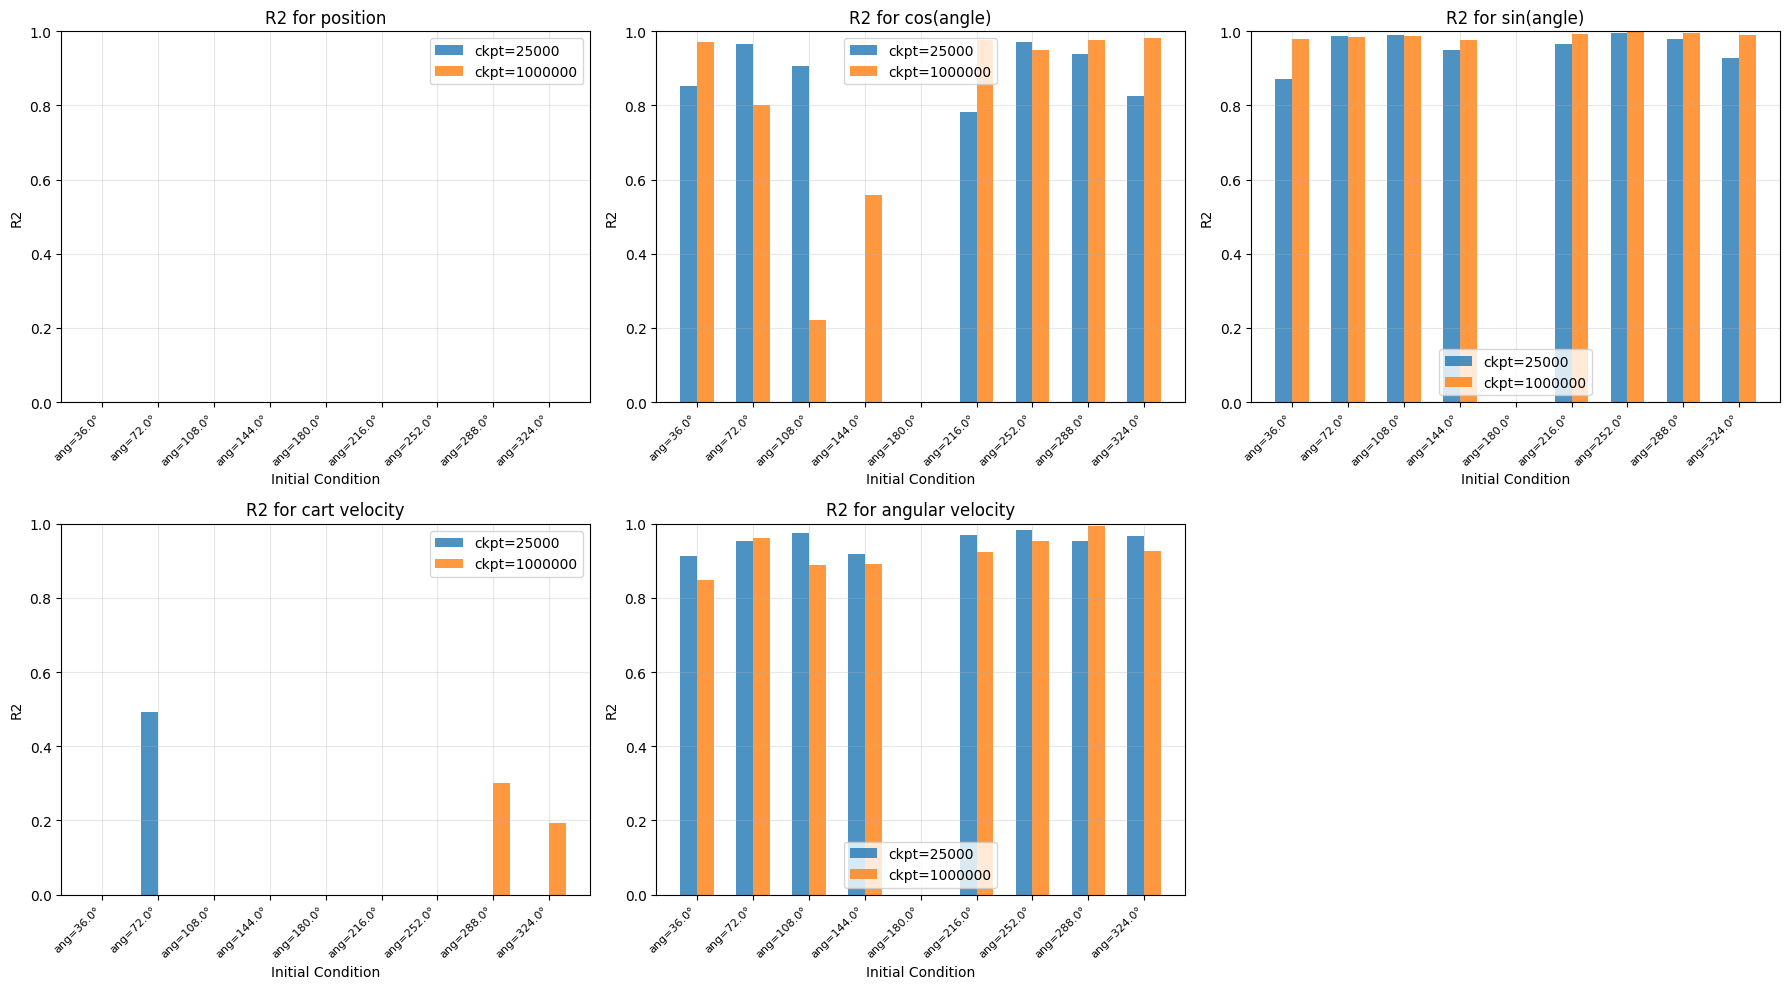

In [181]:
# Plot error_physical_per_dim for two checkpoints across all initial conditions
selected_ckpt1 = 25_000  # Choose a checkpoint to analyze
selected_ckpt2 = 1_000_000  # Choose a checkpoint to analyze

# Collect data for both checkpoints
initial_conditions = []
errors_per_dim_per_ic_ckpt1 = {i: [] for i in range(5)}
errors_per_dim_per_ic_ckpt2 = {i: [] for i in range(5)}

for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int == selected_ckpt1:
        if (initial_position, initial_angle) not in initial_conditions:
            initial_conditions.append((initial_position, initial_angle))
        error_per_dim = results[key]['r2_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt1[dim].append(error_per_dim[dim])
    elif ckpt_int == selected_ckpt2:
        error_per_dim = results[key]['r2_physical_per_dim']
        for dim in range(5):
            errors_per_dim_per_ic_ckpt2[dim].append(error_per_dim[dim])

# Option to sort by angle proximity to 0/360 degrees
sort_by_angle_proximity = False  # Set to True to sort by proximity to 0/360

if sort_by_angle_proximity:
    # Sort initial conditions by how close angle is to 0/360 degrees
    # Use min distance to 0 or 360
    def angle_distance_to_zero(angle):
        return min(abs(angle), abs(angle - 360))

    # Create list of (index, initial_condition) pairs and sort
    indexed_ics = list(enumerate(initial_conditions))
    indexed_ics.sort(key=lambda x: angle_distance_to_zero(x[1][1]))

    # Reorder everything according to the sorted indices
    sort_indices = [idx for idx, _ in indexed_ics]
    initial_conditions = [initial_conditions[i] for i in sort_indices]

    for dim in range(5):
        errors_per_dim_per_ic_ckpt1[dim] = [
            errors_per_dim_per_ic_ckpt1[dim][i] for i in sort_indices
        ]
        errors_per_dim_per_ic_ckpt2[dim] = [
            errors_per_dim_per_ic_ckpt2[dim][i] for i in sort_indices
        ]

# Create labels for initial conditions
ic_labels = [f"ang={ang:.1f}°" for pos, ang in initial_conditions]

# Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

x = np.arange(len(initial_conditions))
width = 0.3  # Width of bars

for dim in range(5):
    ax = axes[dim]
    ax.bar(x - width / 2,
           errors_per_dim_per_ic_ckpt1[dim],
           width,
           label=f'ckpt={selected_ckpt1}',
           alpha=0.8)
    ax.bar(x + width / 2,
           errors_per_dim_per_ic_ckpt2[dim],
           width,
           label=f'ckpt={selected_ckpt2}',
           alpha=0.8)
    ax.set_xlabel('Initial Condition')
    ax.set_ylabel('R2')
    ax.set_title(f'R2 for {variable_names[dim]}')
    ax.set_xticks(x)
    ax.set_xticklabels(ic_labels, rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

# Remove the extra subplot
axes[5].remove()

plt.tight_layout()
plt.show()

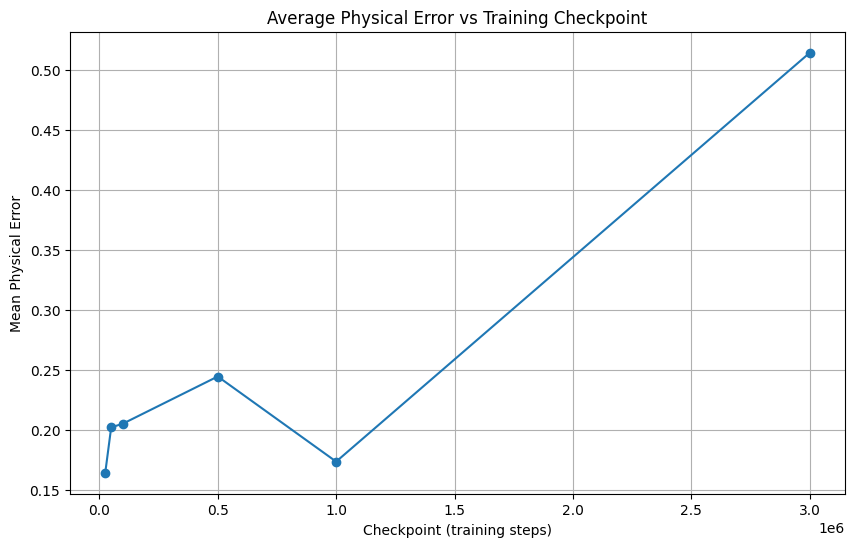

In [20]:
# Compute average error_physical for each checkpoint
ckpt_errors = {}
for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int not in ckpt_errors:
        ckpt_errors[ckpt_int] = []
    ckpt_errors[ckpt_int].append(results[key]['errors_physical'].mean())

# Compute mean error for each checkpoint
ckpt_mean_errors = {
    ckpt: np.mean(errors) for ckpt, errors in ckpt_errors.items()
}

# Sort by checkpoint for plotting
ckpts = sorted(ckpt_mean_errors.keys())
mean_errors = [ckpt_mean_errors[ckpt] for ckpt in ckpts]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(ckpts, mean_errors, marker='o')
plt.xlabel('Checkpoint (training steps)')
plt.ylabel('Mean Physical Error')
plt.title('Average Physical Error vs Training Checkpoint')
plt.grid(True)
plt.show()

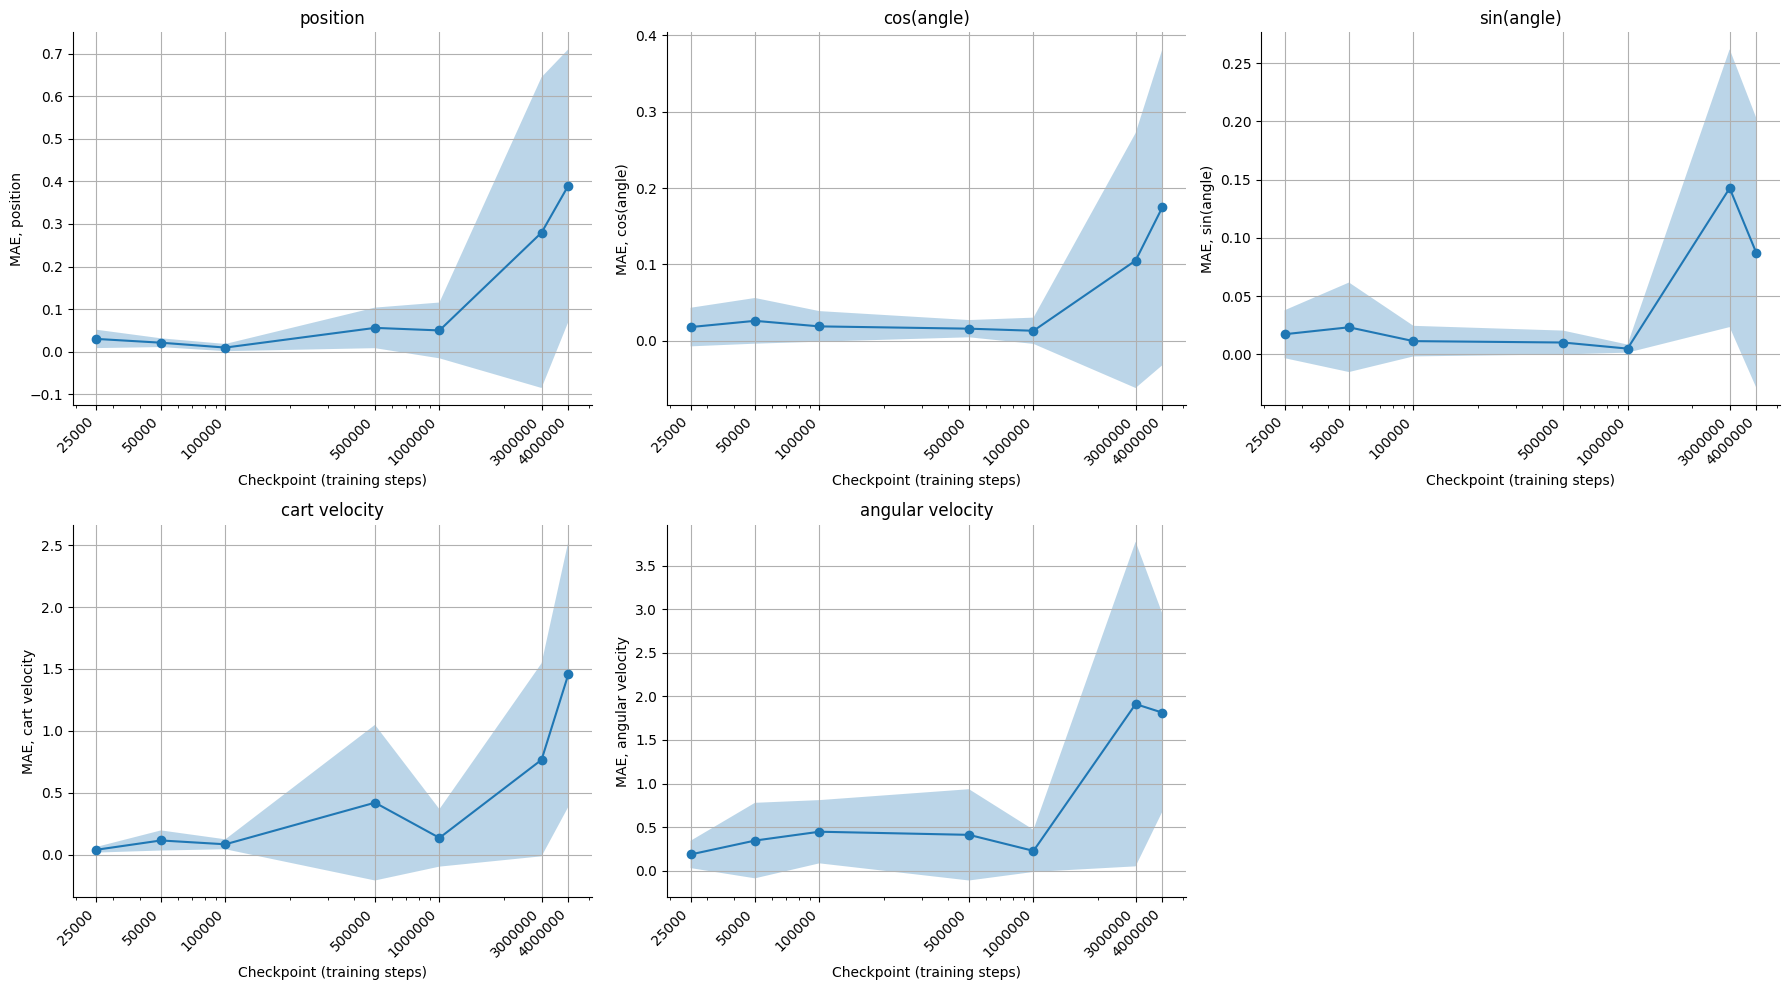

In [184]:
# Plot error_physical_per_dim for each dimension across checkpoints
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

# Collect errors per dimension for each checkpoint
ckpt_errors_per_dim = {}
for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    if ckpt_int not in ckpt_errors_per_dim:
        ckpt_errors_per_dim[ckpt_int] = {dim: [] for dim in range(5)}

    error_per_dim = results[key]['error_physical_per_dim']
    for dim in range(5):
        ckpt_errors_per_dim[ckpt_int][dim].append(error_per_dim[dim])

# Compute mean and std error per dimension for each checkpoint
ckpt_mean_errors_per_dim = {}
ckpt_std_errors_per_dim = {}
for ckpt in ckpt_errors_per_dim.keys():
    ckpt_mean_errors_per_dim[ckpt] = {
        dim: np.mean(ckpt_errors_per_dim[ckpt][dim]) for dim in range(5)
    }
    ckpt_std_errors_per_dim[ckpt] = {
        dim: np.std(ckpt_errors_per_dim[ckpt][dim]) for dim in range(5)
    }

# Sort checkpoints for plotting
ckpts = sorted(ckpt_mean_errors_per_dim.keys())

# Create subplots with 3 plots per row
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for dim in range(5):
    mean_errors_dim = [ckpt_mean_errors_per_dim[ckpt][dim] for ckpt in ckpts]
    std_errors_dim = [ckpt_std_errors_per_dim[ckpt][dim] for ckpt in ckpts]

    axes[dim].plot(ckpts, mean_errors_dim, marker='o')
    axes[dim].fill_between(ckpts,
                           np.array(mean_errors_dim) - np.array(std_errors_dim),
                           np.array(mean_errors_dim) + np.array(std_errors_dim),
                           alpha=0.3)
    axes[dim].set_xlabel('Checkpoint (training steps)')
    axes[dim].set_ylabel(f'MAE, {variable_names[dim]}')
    axes[dim].set_title(f'{variable_names[dim]}')
    axes[dim].set_xscale('log')
    axes[dim].set_xticks(ckpts)
    axes[dim].set_xticklabels([str(ckpt) for ckpt in ckpts],
                              rotation=45,
                              ha='right')
    axes[dim].grid(True)

# Hide the last unused subplot
axes[5].axis('off')
sns.despine()

plt.tight_layout()
plt.show()

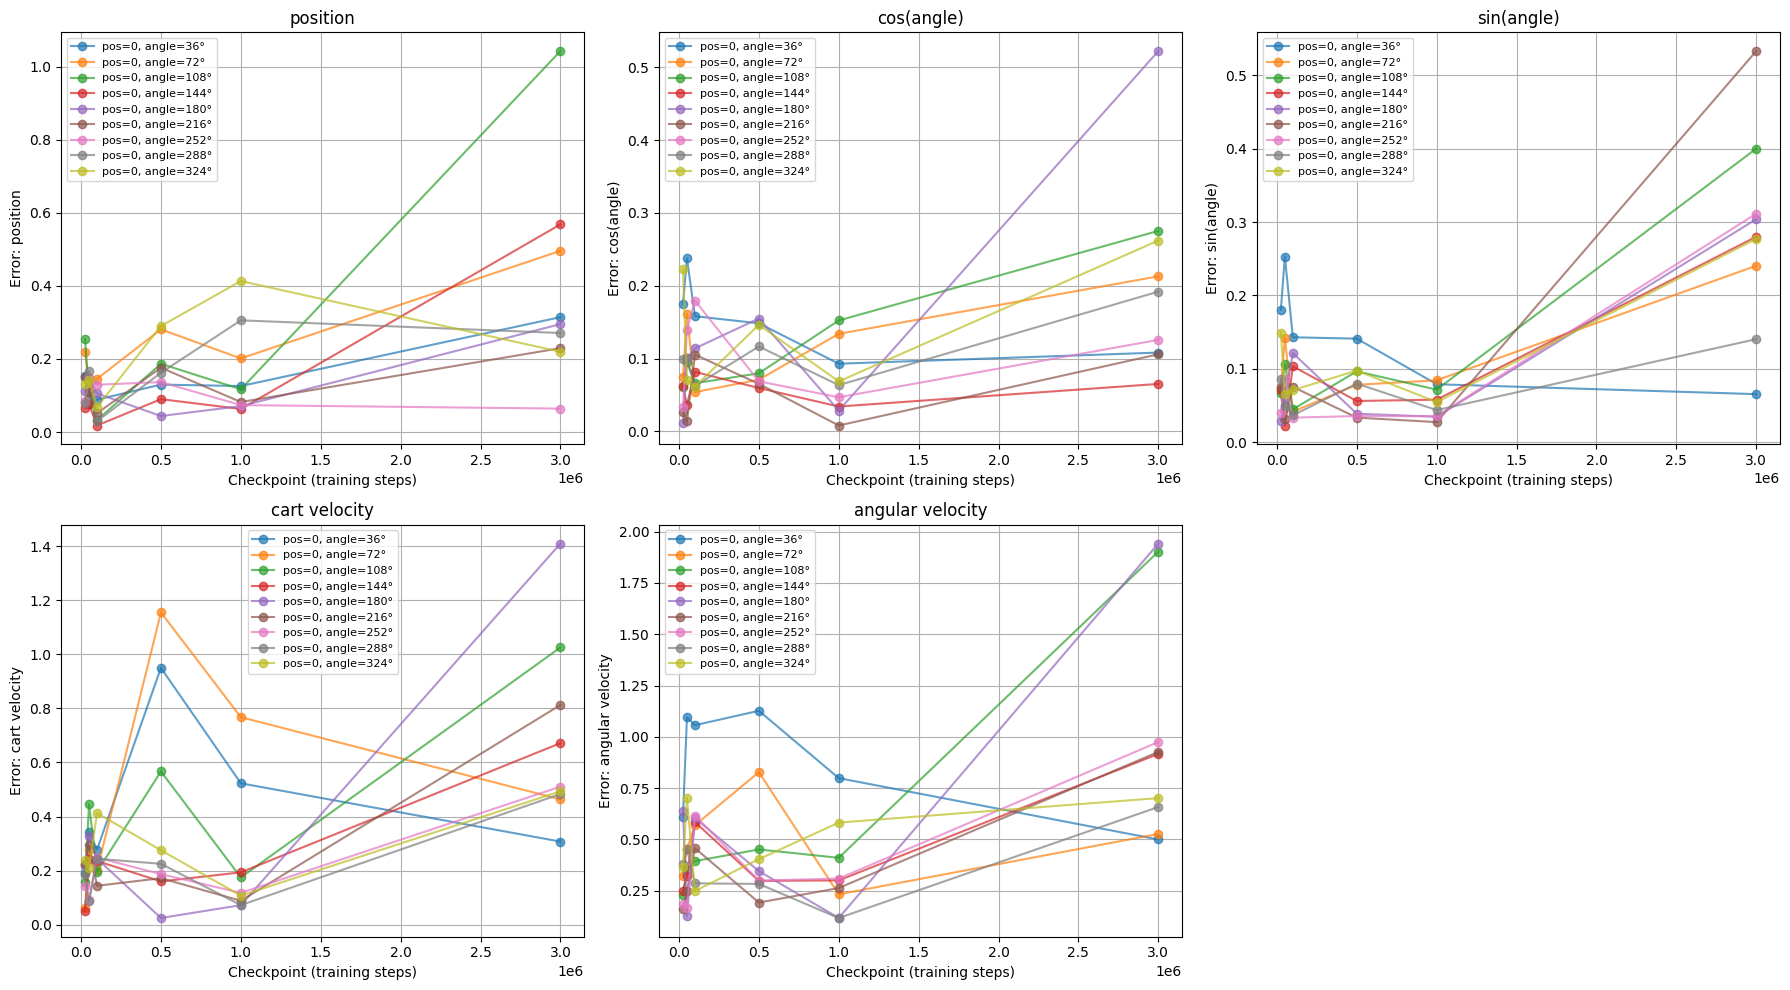

In [22]:
# Plot error_physical_per_dim for each dimension across checkpoints
# One plot per variable, with separate lines for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

# Collect errors per dimension for each checkpoint and initial condition
ckpt_errors_per_dim_per_init = {}
for key in results.keys():
    ckpt_int, initial_position, initial_angle = key
    init_condition = (initial_position, initial_angle)

    if ckpt_int not in ckpt_errors_per_dim_per_init:
        ckpt_errors_per_dim_per_init[ckpt_int] = {}

    if init_condition not in ckpt_errors_per_dim_per_init[ckpt_int]:
        ckpt_errors_per_dim_per_init[ckpt_int][init_condition] = {
            dim: [] for dim in range(5)
        }

    error_per_dim = results[key]['error_physical_per_dim']
    for dim in range(5):
        ckpt_errors_per_dim_per_init[ckpt_int][init_condition][dim].append(
            error_per_dim[dim])

# Get all unique initial conditions
all_init_conditions = set()
for ckpt_data in ckpt_errors_per_dim_per_init.values():
    all_init_conditions.update(ckpt_data.keys())
all_init_conditions = sorted(all_init_conditions)

# Sort checkpoints for plotting
ckpts = sorted(ckpt_errors_per_dim_per_init.keys())

# Create subplots with 3 plots per row
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for dim in range(5):
    # Plot a line for each initial condition
    for init_condition in all_init_conditions:
        errors_for_init = []
        for ckpt in ckpts:
            if init_condition in ckpt_errors_per_dim_per_init[ckpt]:
                # Average over multiple runs with same initial condition (if any)
                errors = ckpt_errors_per_dim_per_init[ckpt][init_condition][dim]
                errors_for_init.append(np.mean(errors))
            else:
                errors_for_init.append(np.nan)

        label = f'pos={init_condition[0]:.0f}, angle={init_condition[1]:.0f}°'
        axes[dim].plot(ckpts,
                       errors_for_init,
                       marker='o',
                       alpha=0.7,
                       label=label)

    axes[dim].set_xlabel('Checkpoint (training steps)')
    axes[dim].set_ylabel(f'Error: {variable_names[dim]}')
    axes[dim].set_title(f'{variable_names[dim]}')
    axes[dim].grid(True)
    axes[dim].legend(fontsize=8, loc='best')

# Hide the last unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()